# Análisis de Regresión Lineal
PBL4 - Grupo 1 <rbr>
Autores: Josu Lazpiur, Egoitz Larrea, Oier Atxa, Eneko Atxa y Anartz Legarda-Ereño
## Proyecto: Gertuko - Plataforma de Comercio Local Sostenible

Este notebook forma parte del estudio estadístico desarrollado para el proyecto "Gertuko", 
una plataforma web que conecta a productores locales con consumidores, fomentando el consumo 
sostenible y de proximidad. El objetivo de este análisis es estudiar la relación entre variables 
relevantes del comercio electrónico local, como la posición de un producto en una lista y su tasa 
de clics o conversión, utilizando técnicas de regresión lineal.

### Introducción

En los últimos años, el interés por los productos locales y sostenibles ha crecido de forma notable. 
Sin embargo, muchos pequeños productores aún tienen dificultades para vender en línea debido a la falta 
de herramientas tecnológicas y visibilidad. El proyecto *Gertuko* busca dar respuesta a este problema 
desarrollando una plataforma digital que conecte directamente a productores y consumidores de una misma zona.

Con este estudio estadístico queremos analizar el comportamiento de los usuarios en plataformas digitales 
similares y estudiar si existe una relación entre variables que puedan afectar al éxito de los productos, 
como por ejemplo su posición en un listado de búsqueda.


### Objetivos del Estudio Estadístico

El propósito de este estudio es analizar la relación entre variables clave del comercio electrónico local 
que podrían influir en la visibilidad y éxito de los productos sostenibles. Para ello, nos proponemos:

- Investigar si existe una correlación entre la posición de un producto en una lista y su tasa de clics.
- Aplicar técnicas de regresión lineal para modelar esta relación y evaluar su fuerza.
- Visualizar gráficamente los datos para interpretar mejor los patrones existentes.
- Proporcionar conclusiones que puedan ser útiles en el diseño de la plataforma Gertuko, optimizando la forma en que se presentan los productos a los consumidores.

### Relación con los Objetivos de Desarrollo Sostenible (ODS)

Este proyecto se alinea principalmente con dos ODS:

- **ODS 12: Producción y consumo responsables**  
  Al fomentar la compra de productos locales y sostenibles, se reduce la huella de carbono y se promueve un modelo de consumo más consciente y responsable.

- **ODS 8: Trabajo decente y crecimiento económico**  
  Al empoderar a pequeños productores mediante herramientas digitales, se mejora su acceso al mercado, promoviendo un desarrollo económico inclusivo.

El análisis estadístico ayuda a entender mejor el impacto potencial de este tipo de plataformas, aportando datos que pueden apoyar la toma de decisiones tanto técnicas como estratégicas.


### Datos

Para este estudio, utilizamos el conjunto de datos conocido como **AOL Query Logs (2006)**, una colección de registros de búsqueda publicada por AOL en agosto de 2006. Este dataset contiene aproximadamente 20 millones de consultas realizadas por más de 650,000 usuarios durante un período de tres meses, de marzo a mayo de 2006. Aunque los usuarios fueron identificados mediante números anónimos, muchas consultas incluían información personal, lo que generó preocupaciones significativas sobre la privacidad. AOL retiró el archivo pocos días después de su publicación, pero para entonces ya se había distribuido ampliamente y sigue estando disponible para investigación académica.

El dataset incluye los siguientes campos:

- `AnonID`: Identificador anónimo del usuario.
- `Query`: Término de búsqueda introducido por el usuario.
- `QueryTime`: Fecha y hora en que se realizó la consulta.
- `ItemRank`: Posición del resultado en la lista de resultados de búsqueda.
- `ClickURL`: URL del enlace en el que el usuario hizo clic, si corresponde.

Este conjunto de datos permite analizar la distribución de clics según la posición (ItemRank) de los resultados, es decir, qué proporción de los clics recibe cada puesto en la lista de resultados. Sin embargo, no es posible calcular métricas como el Click-Through Rate (CTR) de forma precisa, ya que el dataset solo registra los enlaces que fueron clicados y no incluye información sobre todos los resultados mostrados que no recibieron clic.



### Metodología de Selección y Clasificación de Datos

El proceso de selección y clasificación de datos se llevó a cabo de la siguiente manera:
<ol> <li><strong>Filtrado Inicial de Datos:</strong></li> <p>Se utilizaron los archivos <code>user-ct-test-collection-01.txt</code> y <code>user-ct-test-collection-02.txt</code> del conjunto de datos <em>AOL Query Logs (2006)</em>, los cuales fueron concatenados en un único DataFrame para facilitar su análisis. A continuación, se eliminaron todas las entradas que no contenían clics, es decir, aquellas filas en las que el campo <code>ClickURL</code> estaba vacío o era nulo.</p> <li><strong>Clasificación de Datos:</strong></li> <p>Tras el filtrado, se procedió a clasificar los datos en función de la posición que ocupaban los resultados clicados (campo <code>ItemRank</code>) en la lista devuelta por el buscador. Se calcularon las métricas agregadas de clics totales por posición con el fin de estudiar el comportamiento del usuario frente a los resultados presentados en distintos rangos de visibilidad.</p> <ul> <li><b>Clicks por Posición (ItemRank):</b> Se agruparon todas las entradas por su valor de <code>ItemRank</code> y se contabilizó el número total de veces que los usuarios hicieron clic en resultados en esa posición.</li> <li><b>Análisis limitado a las primeras posiciones:</b> Para centrarse en el comportamiento más relevante, el análisis visual se restringió a las posiciones comprendidas entre el 1 y el 30, que representan la parte superior de los resultados de búsqueda.</li> </ul> <li><strong>Conversión y Preparación de Datos:</strong></li> <p>Se prepararon los datos para distintos tipos de análisis estadístico y de regresión, incluyendo transformaciones como la aplicación de logaritmos al número de clics con el fin de facilitar modelos de regresión lineal o exponencial. Además, se generaron subconjuntos específicos del conjunto completo, como por ejemplo los clics por dominio, para realizar comparaciones más concretas.</p> </ol>

## Estudio

#### Importación de librerias

In [18]:
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t

### Carga de datos
A continuación, cargamos las variables del dataset de AOL como se menciono en el apartado de Datos.

In [19]:
# Lista con las rutas de los archivos que vamos a cargar
archivos = [
    'Data/user-ct-test-collection-01.txt',
    'Data/user-ct-test-collection-02.txt'
]

# Cargamos los archivos y los unimos en un único DataFrame
dfs = []
for archivo in archivos:
    df_temp = pd.read_csv(
        archivo,
        sep='\t',
        names=['AnonID', 'Query', 'QueryTime', 'ItemRank', 'ClickURL'],
        quoting=3,
        encoding='utf-8',
        on_bad_lines='skip'
    )
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)


C:\Users\eneko\AppData\Local\Temp\ipykernel_26784\1457958977.py:10: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(
C:\Users\eneko\AppData\Local\Temp\ipykernel_26784\1457958977.py:10: DtypeWarning: Columns (0,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(


### Filtrado de datos
Eliminamos los valores no numéricos de ItemRank,  filtramos las posiciones del 1 al 30.

In [20]:
# Aseguramos que 'ItemRank' sea numérico, si no puede convertirse, se marca como NaN
df['ItemRank'] = pd.to_numeric(df['ItemRank'], errors='coerce')

# Quitamos las filas con valores no el valor NaN en 'ItemRank'
df = df.dropna(subset=['ItemRank'])

# Nos quedamos solo con posiciones entre 1 y 30 
df = df[df['ItemRank'].between(1, 30)]

print(f"Total de datos válidos: {len(df)}")


Total de datos válidos: 3682186


#### Cantidad de visitas por cada posición de la lista

En el siguente histograma aparecen la cantidad de visitas totales de cada posicion.

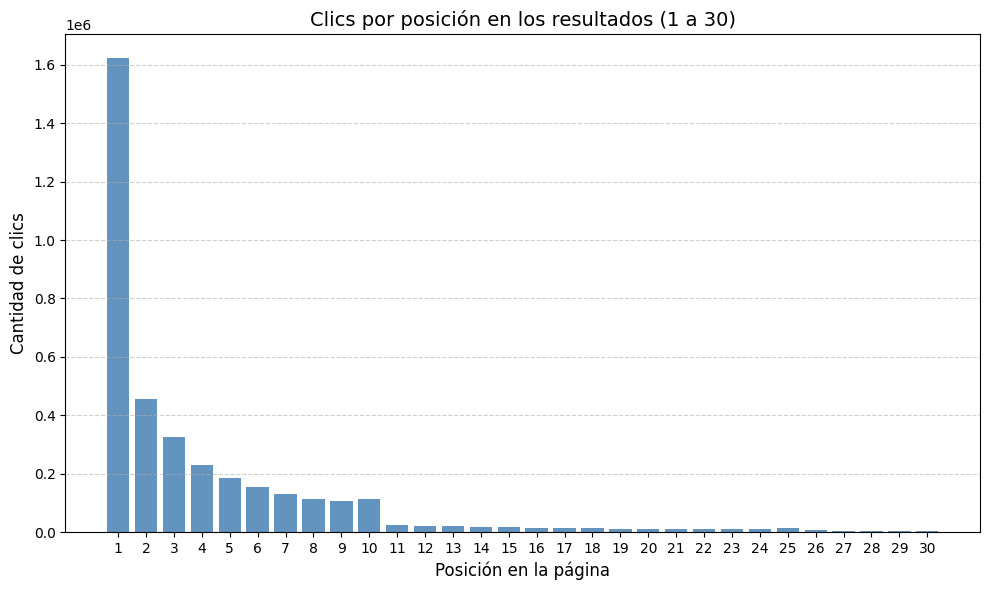

In [21]:
# Contamos cuántas veces se ha hecho clic en cada posición
clics_por_posicion = df.groupby('ItemRank').size().reset_index(name='veces_clicado')

# Aseguramos que estén ordenadas por posición
clics_por_posicion = clics_por_posicion.sort_values('ItemRank')


# Mostramos el número de clics por cada posición (del 1 al 30)
plt.figure(figsize=(10, 6))
plt.bar(
    clics_por_posicion['ItemRank'],
    clics_por_posicion['veces_clicado'],
    color='steelblue',
    alpha=0.85
)
plt.title('Clics por posición en los resultados (1 a 30)', fontsize=14)
plt.xlabel('Posición en la página', fontsize=12)
plt.ylabel('Cantidad de clics', fontsize=12)
plt.xticks(range(1, 31))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Hemos decidido dividir estos datos por dominio y posición para que se puedan comparar los resultados de un mismo dominio en las diferentes posiciones.

In [22]:
# Extrae el dominio de una URL (quitando el 'www.' si lo tiene)
def extraer_dominio(url):
    try:
        dominio = urlparse(url).netloc
        return dominio[4:] if dominio.startswith('www.') else dominio
    except:
        return ''

# Creamos una nueva columna con el dominio
df['Dominio'] = df['ClickURL'].apply(extraer_dominio)

Una vez con los datos agrupados por dominio, hemos filtrado aquellos dominios que no hayan sido clicados en todas las posiciones del 1 al 30. Ya que, como los datos que tenemos son solo los dominios que si han sido clicados, queremos evitar aquellos que tienen pocas visitas en las primeras posiciones y no tienen visitas en las posteriores para que estos bajen la media de las primeras posiciones injustamente.

In [23]:
# Se agrupan los clics por dominio y posición en los resultados
clicks_por_dominio_y_posicion = df.groupby(['Dominio', 'ItemRank']).size().reset_index(name='veces_clicado')

# Contar cuántas filas tiene cada dominio
conteo_filas_por_dominio = clicks_por_dominio_y_posicion.groupby('Dominio').size()

# Filtrar dominios que tienen exactamente 30 posiciones
dominios_con_30 = conteo_filas_por_dominio[conteo_filas_por_dominio == 30].index

# Filtrar el DataFrame original para quedarte solo con esos dominios
clicks_dominios_completos = clicks_por_dominio_y_posicion[clicks_por_dominio_y_posicion['Dominio'].isin(dominios_con_30)]

# Mostramos cuántos dominios cumplen esta condición
print(f"Número de dominios con al menos un clic en todas las posiciones del 1 al 30: {len(dominios_con_30)}")

# Se preparan las variables X e Y
X = clicks_dominios_completos['ItemRank'].values
Y = clicks_dominios_completos['veces_clicado'].values
print(Y.sum())

Número de dominios con al menos un clic en todas las posiciones del 1 al 30: 74
315717


Así es como se ven los datos representados de forma grafica, cada punto representa la cantidad de visitas recibidas por un dominio en una posición.

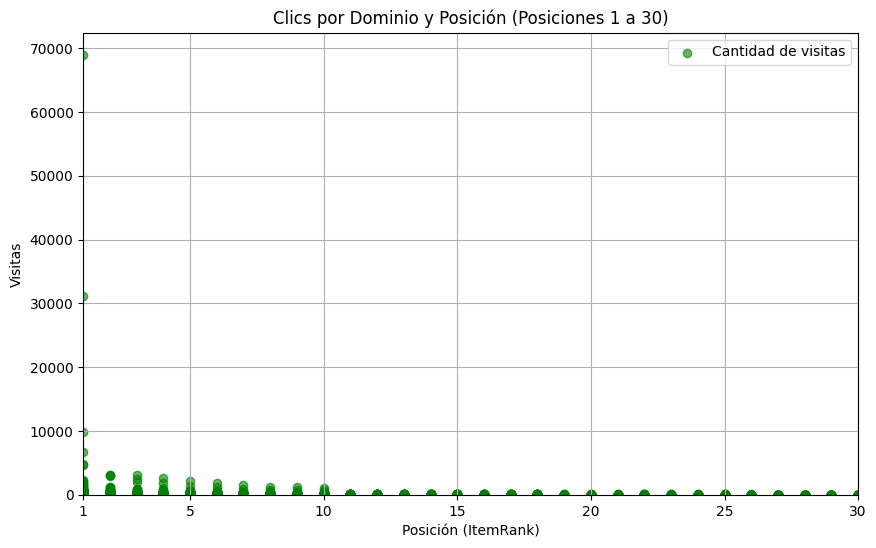

In [24]:
plt.figure(figsize=(10, 6))
plt.title('Clics por Dominio y Posición (Posiciones 1 a 30)')
plt.scatter(X, Y, color='green', alpha=0.6, label='Cantidad de visitas')

plt.ylim(bottom=0)
plt.xlim(1, 30)
plt.xticks([1, 5, 10, 15, 20, 25, 30])

plt.xlabel('Posición (ItemRank)')
plt.ylabel('Visitas')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

Como los clics caen muy rápido según la posición, vimos que los datos siguen una distribución tipo potencia.
Para analizarlo mejor, aplicamos un logaritmo solo al eje Y (clics).
Así la relación se vuelve más lineal y podemos ajustarla con un modelo.

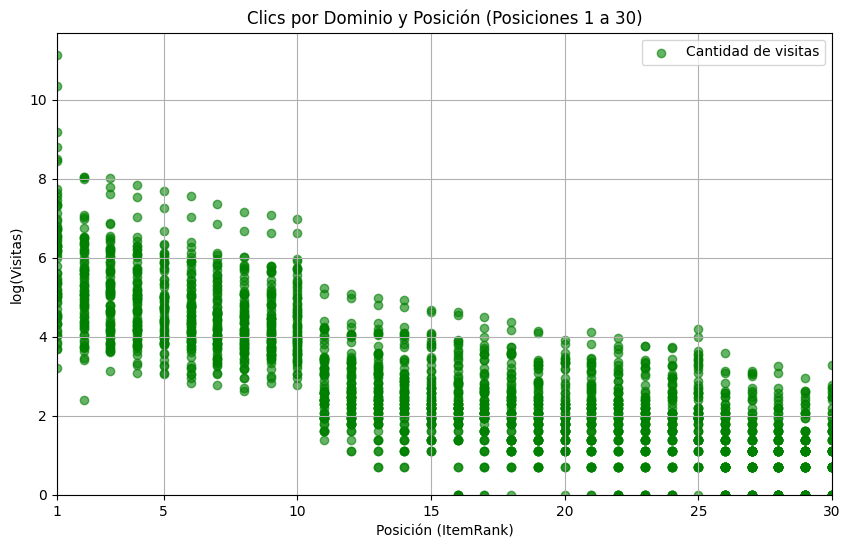

In [25]:
Y_log = np.log(Y)

# Se visualiza la relación logarítmica entre posición y clics
plt.figure(figsize=(10, 6))
plt.title('Clics por Dominio y Posición (Posiciones 1 a 30)')
plt.scatter(X, Y_log, color='green', alpha=0.6, label='Cantidad de visitas')

plt.ylim(bottom=0)
plt.xlim(1, 30)
plt.xticks([1, 5, 10, 15, 20, 25, 30])

plt.xlabel('Posición (ItemRank)')
plt.ylabel('log(Visitas)')
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

Hasta ahora hemos visto que los clics bajan bastante según la posición del resultado, pero para saber si esa relación es realmente significativa y no una simple casualidad, vamos a hacer una prueba estadística.

Lo que queremos comprobar es si existe una correlación clara entre la posición y el número de clics, o si esa relación podría deberse al azar.

### Hipótesis

H₀ (hipótesis nula): No hay relación entre la posición y los clics (correlación cero).

H₁ (hipótesis alternativa): Sí hay una relación significativa entre ambas variables (correlación distinta de cero).

#### Cálculo del Coeficiente de Correlación de Pearson:
El coeficiente de correlación de Pearson (r) mide la fuerza y dirección de la relación lineal entre dos variables.

Su fórmula es:

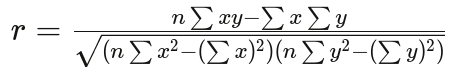


Donde:

n = número de observaciones

x = variable independiente (posición)

y = variable dependiente (log de clics)

In [26]:
n = len(X)

i = n * np.sum(X * Y_log) - np.sum(X) * np.sum(Y_log)
m =  np.sqrt((n * np.sum(X**2) - np.sum(X)**2) * (n * np.sum(Y_log**2) - np.sum(Y_log)**2))

r = i / m

print("Coeficiente de correlación: " + str(r))

Coeficiente de correlación: -0.8014091615171303


Prueba de Significancia Estadística:

Para determinar si la correlación observada es estadísticamente significativa, utilizamos el estadístico t de Student:


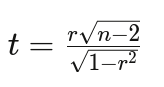

Este estadístico sigue una distribución t con (n-2) grados de libertad bajo la hipótesis nula.

In [27]:

# Calculo de T student
i = r * np.sqrt(n - 2)
m = np.sqrt(1 - r**2)

T = i/m

print("T: " + str(T))

alpha = 0.05 
umbral  = t.ppf(1 - alpha/2, n - 2)

print(f"Umbral de t para un intervalo de confianza del {1 - alpha}: {umbral}")

# Evaluación de la hipótesis
if abs(T) > umbral:
    print("Hipótesis nula rechazada")
else:
    print("Hipótesis nula no rechazada")

T: -63.102895211464386
Umbral de t para un intervalo de confianza del 0.95: 1.961034112715069
Hipótesis nula rechazada


### Conclusión Hipótesis
Tras aplicar el test de hipótesis, los resultados obtenidos nos permiten rechazar con claridad la hipótesis nula. El coeficiente de correlación obtenido (r = -0.8014) indica una relación negativa bastante fuerte entre la posición en los resultados de búsqueda y el número de clics: cuanto más abajo aparece un resultado, menos clics recibe.

Además, el valor del estadístico T calculado supera ampliamente el valor crítico para un nivel de confianza del 95%, lo que refuerza la idea de que esta relación no es fruto del azar, sino que existe una conexión real y significativa entre ambas variables.

En resumen, podemos afirmar que la posición influye de forma importante en la probabilidad de que un resultado sea clicado.



### Regresión lineal
Para ver mejor cómo afecta la posición al número de clics, usamos una regresión lineal. Esta herramienta nos ayuda a trazar una línea que resume la tendencia general: en este caso, que los clics bajan cuanto más abajo aparece un resultado. Así podemos medir esa relación de forma clara y sencilla.



La regresión lineal simple modela la relación entre una variable independiente (X) y una dependiente (Y) mediante la ecuación:


Donde:

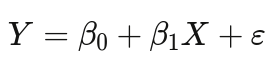

β₀ = intercepto (valor de Y cuando X = 0)

β₁ = pendiente (cambio en Y por unidad de cambio en X)

ε = término de error


##### Estimación por Mínimos Cuadrados:
Los valores se calculan minimizando la suma de cuadrados de los residuos:

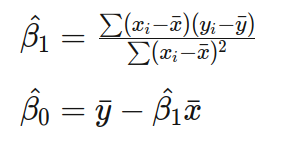


En nuestro caso utilizamos la función np.polyfit para calcularlos.

b1: -0.15758479882104198
b0: 5.37973205859731


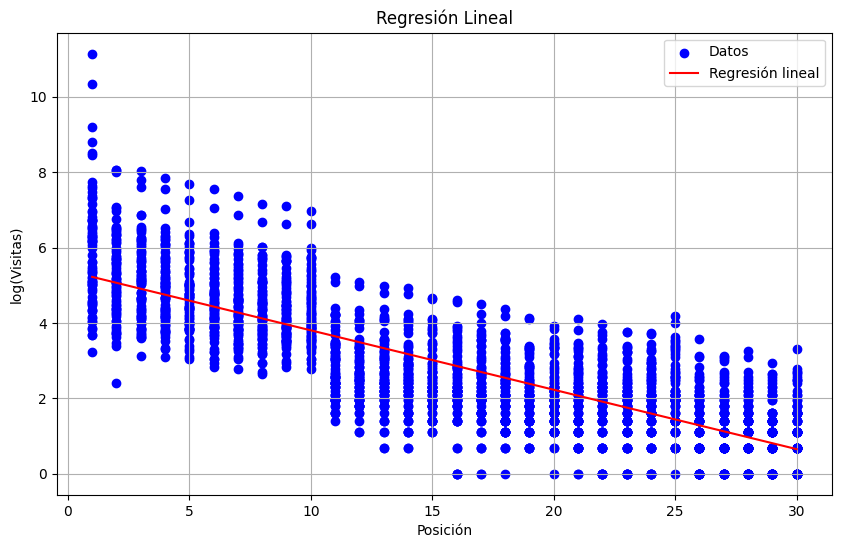

In [28]:
b1, b0 = np.polyfit(X, Y_log, 1)


print("b1: " + str(b1))
print("b0: " + str(b0))

# Calcular regresión lineal
regresion_Y = b0 + b1 * X

plt.figure(figsize=(10, 6))
plt.scatter(X, Y_log, color='blue', label='Datos') 
plt.plot(X, regresion_Y, color='red', label='Regresión lineal')
plt.title('Regresión Lineal')
plt.xlabel('Posición')
plt.ylabel('log(Visitas)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

### Intervalos de Confianza y Predicción

Gracias a la regresión lineal, se puede determinar en qué rango es probable que se encuentren los siguientes conjuntos de datos. Este rango se llama intervalo de predicción y ayuda a realizar predicciones sobre observaciones individuales con un nivel de confianza definido.

##### 1. Error Estándar de la Regresión:

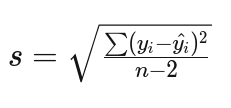

##### 2. Intervalo de Predicción para una observación individual:

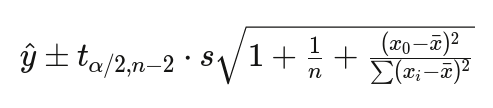

##### 3. Intervalo de Confianza para la respuesta media:

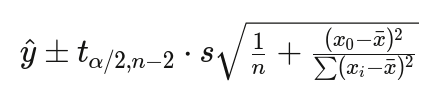

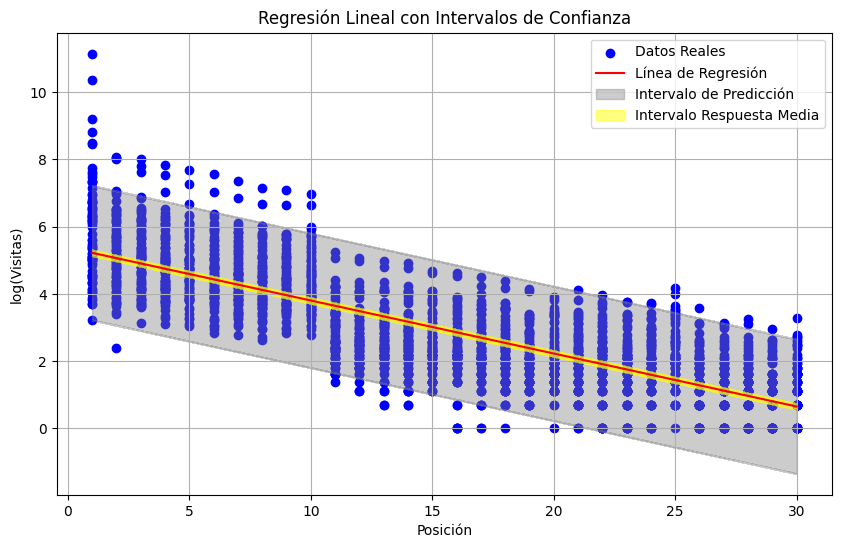

In [29]:
# Variables anteriores:
# - n
# - X, Y_log
# - b0, b1
# - valor_critico
# - regresion_Y = b0 + b1 * X

# Media y suma de cuadrados
media_x = np.mean(X)
suma_cuadrados = np.sum((X - media_x)**2)

# Cálculo del error estándar residual de la regresión
errores = Y_log - regresion_Y
error_estandar = np.sqrt(np.sum(errores**2) / (n - 2))

# Margen de error para el intervalo de predicción
margen_error_pred = umbral  * error_estandar * np.sqrt(1 + 1/n + ((X - media_x)**2 / suma_cuadrados))
lim_inf_pred = regresion_Y - margen_error_pred
lim_sup_pred = regresion_Y + margen_error_pred

# Margen de error para la respuesta media
margen_error_media = umbral  * error_estandar * np.sqrt(1/n + ((X - media_x)**2 / suma_cuadrados))
lim_inf_media = regresion_Y - margen_error_media
lim_sup_media = regresion_Y + margen_error_media

# Gráfico con ambos intervalos
plt.figure(figsize=(10, 6))
plt.scatter(X, Y_log, color='blue', label='Datos Reales')
plt.plot(X, regresion_Y, color='red', label='Línea de Regresión')

plt.fill_between(X, lim_inf_pred, lim_sup_pred, color='grey', alpha=0.4, label='Intervalo de Predicción')
plt.fill_between(X, lim_inf_media, lim_sup_media, color='yellow', alpha=0.5, label='Intervalo Respuesta Media')

plt.title('Regresión Lineal con Intervalos de Confianza')
plt.xlabel('Posición')
plt.ylabel('log(Visitas)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

### **Conclusión del Gráfico**
Este gráfico representa la relación entre la posición (ItemRank) de un dominio y el logaritmo del número de veces que fue clicado, junto con su intervalo de predicción (en bandas grises). Observamos que, a medida que la posición del dominio aumenta (es decir, baja en el ranking), el número esperado de clics disminuye significativamente, lo cual es visualizado mediante la línea de regresión negra decreciente. El intervalo de predicción ofrece una estimación del rango en el que podrían situarse futuras observaciones de clics para una posición determinada, reflejando la incertidumbre natural del modelo y facilitando un análisis más realista del comportamiento de los usuarios ante los resultados presentados.

Implementacion en Java

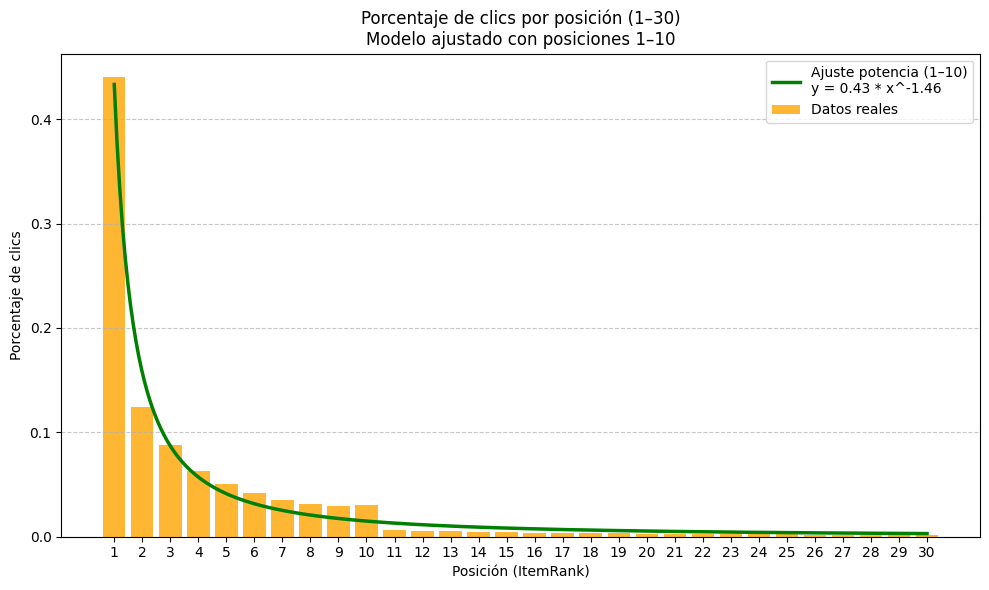

In [30]:
# Calcular el porcentaje de clics por posición
total_clics = clics_por_posicion['veces_clicado'].sum()
clics_por_posicion['porcentaje_clics'] = clics_por_posicion['veces_clicado'] / total_clics

# Usar solo posiciones 1 a 10 para ajustar el modelo
clics_1_10 = clics_por_posicion[clics_por_posicion['ItemRank'].between(1, 10)].copy()
X_fit_base = clics_1_10['ItemRank'].values
Y_fit_base = clics_1_10['porcentaje_clics'].values

# Modelo de potencia: y = a * x^b
def modelo_potencia(x, a, b):
    return a * (x ** b)

# Ajustar el modelo a los datos
params_pow, _ = curve_fit(modelo_potencia, X_fit_base, Y_fit_base, p0=[max(Y_fit_base), -1])
a_pow, b_pow = params_pow

# Crear curva suave para graficar el ajuste
X_suave = np.linspace(1, 30, 300)
Y_suave_pow = modelo_potencia(X_suave, a_pow, b_pow)

# Graficar datos reales y curva ajustada
plt.figure(figsize=(10, 6))
plt.bar(clics_por_posicion['ItemRank'], clics_por_posicion['porcentaje_clics'],
        color='orange', alpha=0.8, label='Datos reales')
plt.plot(X_suave, Y_suave_pow, color='green', linewidth=2.5,
         label=f'Ajuste potencia (1–10)\ny = {a_pow:.2f} * x^{b_pow:.2f}')

plt.title('Porcentaje de clics por posición (1–30)\nModelo ajustado con posiciones 1–10')
plt.xlabel('Posición (ItemRank)')
plt.ylabel('Porcentaje de clics')
plt.xticks(range(1, 31))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


## **Conclusiones del Estudio**

El análisis realizado ha demostrado de manera clara que existe una relación inversamente proporcional y estadísticamente significativa entre la posición de los resultados (ItemRank) en un listado y la cantidad de clics que estos reciben. Esto confirma que la visibilidad, medida a través de la posición en el ranking, influye de forma directa en el comportamiento de los usuarios en entornos digitales.

A través del modelo de regresión logarítmica aplicado, se observó que los dominios ubicados en posiciones más elevadas obtienen un número significativamente mayor de clics, lo que respalda la hipótesis de que la atención de los usuarios disminuye rápidamente a medida que se desciende en la lista.

Desde una perspectiva práctica, los resultados de este estudio nos impulsan a aprovechar esta dinámica de visibilidad para rediseñar el orden de presentación de los resultados en nuestra aplicación. En lugar de priorizar los productos en función de su volumen de ventas, lo que tiende a beneficiar únicamente a los actores más grande, optaremos por clasificarlos según la media de las valoraciones otorgadas por los usuarios. De este modo, nuestra aplicación promoverá aquellos productos que destacan por su calidad percibida, independientemente de su tamaño de mercado, favoreciendo así a productores medianos y pequeños que hacen bien las cosas. 